In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from colliderml_electron import io, plots

REPO_ROOT = Path.cwd()

while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

print("Repo root:", REPO_ROOT)

Repo root: /Users/loiclambert/code/colliderml-electron-calo


/Users/loiclambert/code/colliderml-electron-calo/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load data
io.load_frames(channel="zee", pileup="pu200", max_events=50)

frames = io.load_frames(
    channel="zee",
    pileup="pu200",
    max_events=5,
)

frames.keys()

# inspect variables
print("particles:", frames["particles"].shape)
print("calo_hits:", frames["calo_hits"].shape)

frames["particles"].head()
frames["calo_hits"].head()

particles: (5, 18)
calo_hits: (5, 9)


event_id,detector,total_energy,x,y,z,contrib_particle_ids,contrib_energies,contrib_times
u32,list[u8],list[f32],list[f32],list[f32],list[f32],list[list[u64]],list[list[f32]],list[list[f32]]
0,"[11, 10, … 9]","[0.001475, 0.002533, … 0.000155]","[142.800003, -96.900002, … 362.17688]","[1086.888916, -1267.550049, … -634.487366]","[3263.0, -1754.400024, … -3278.149902]","[[172284], [176942, 176947, … 176949], … [187857]]","[[0.001475], [0.000662, 0.000659, … 0.000355], … [0.000155]]","[[11.443049], [7.320939, 7.333857, … 7.328927], … [11.102481]]"
1,"[11, 10, … 11]","[0.00019, 0.000171, … 0.000906]","[464.688965, 375.613434, … 102.105339]","[35.700001, 1200.003784, … 433.081299]","[3252.899902, 2555.100098, … 3212.5]","[[100857], [134475], … [88708, 88707, 124998]]","[[0.00019], [0.000171], … [0.00014, 0.000154, 0.000611]]","[[10.783903], [10.528381], … [11.000131, 11.000216, 11.181238]]"
2,"[10, 14, … 9]","[0.000222, 0.001092, … 0.000223]","[1075.862915, -951.381897, … 122.400002]","[-866.700806, 296.659973, … 836.988953]","[-2580.600098, 3698.5, … -3303.399902]","[[165514], [195989, 13882], … [163001]]","[[0.000222], [0.000536, 0.000556], … [0.000223]]","[[9.976664], [13.039487, 12.685358], … [11.382099]]"
3,"[10, 11, … 9]","[0.000209, 0.001091, … 0.000157]","[693.474792, 61.200001, … -530.019653]","[-1101.137817, 479.988953, … -307.864532]","[-71.400002, 3232.699951, … -3217.550049]","[[50428], [123638], … [51063]]","[[0.000209], [0.001091], … [0.000157]]","[[5.410149], [11.0409], … [11.408113]]"
4,"[9, 11, … 12]","[0.000204, 0.000077, … 0.000498]","[-102.0, 127.5, … 540.391479]","[745.188965, 765.588989, … 191.365707]","[-3263.0, 3318.550049, … -4922.5]","[[97933], [162904], … [199886]]","[[0.000204], [0.000077], … [0.000498]]","[[11.352382], [11.455146], … [16.556728]]"


In [3]:
p_row, c_row = io.get_event(frames, 0)
electrons = io.prompt_electrons(p_row)

print(f"Number of prompt electrons in event 0: {len(electrons)}")
electrons

Number of prompt electrons in event 0: 2


[{'particle_id': 233,
  'pdg_id': 11,
  'px': 12.084962844848633,
  'py': -28.288488388061523,
  'pz': 9.763503074645996,
  'energy': 32.27399826049805},
 {'particle_id': 234,
  'pdg_id': -11,
  'px': 4.62752628326416,
  'py': 64.30288696289062,
  'pz': 66.0659408569336,
  'energy': 92.30917358398438}]

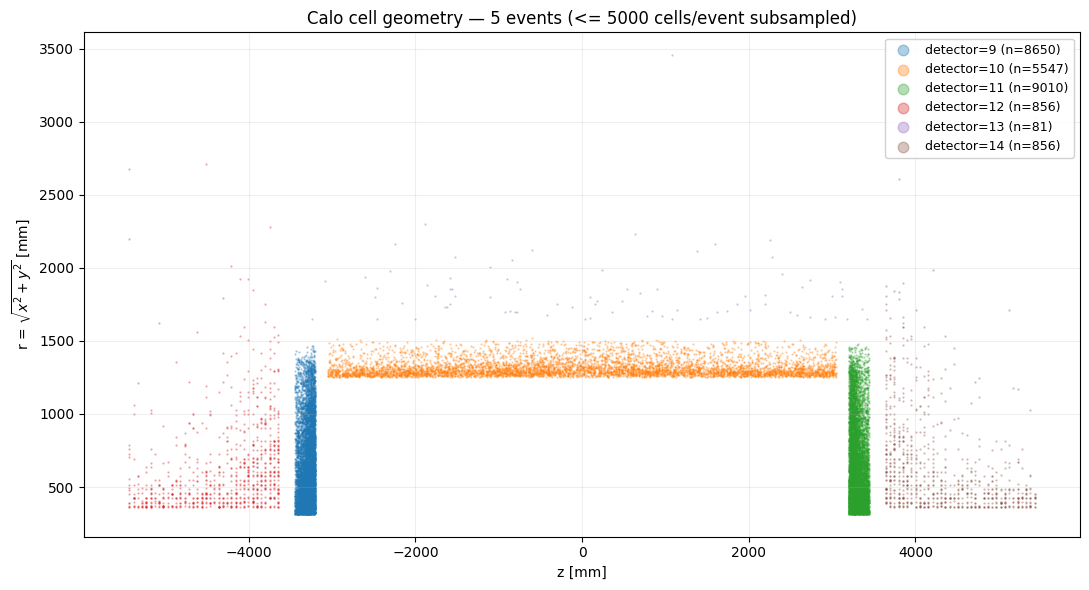

In [ ]:
# show calorimeter cell geometry in the rz plane
fig = plots.detector_geometry(
    frames,
    n_events=5,
    max_cells_per_event=5000,
)
plt.show()

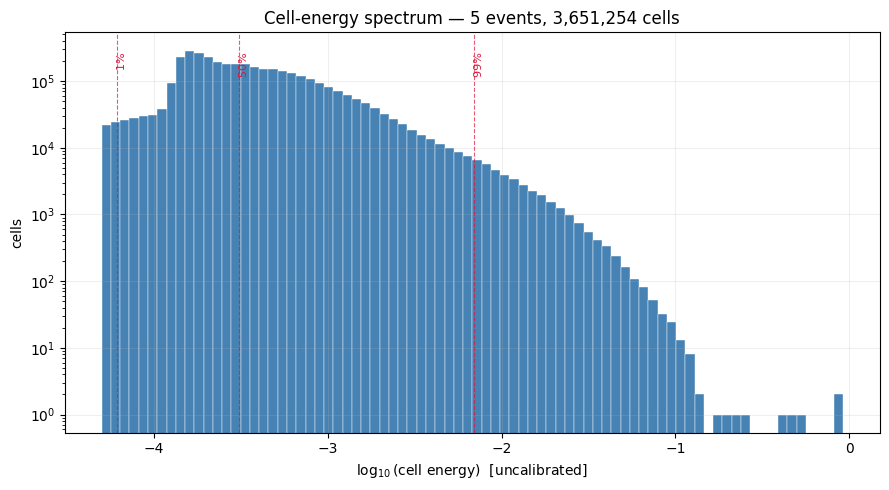

In [6]:
# show cell energy spectrum
# distribution of calorimeter cell energies on a log scale
fig = plots.cell_energy_spectrum(
    frames,
    n_events=5,
    bins=80,
)
plt.show()

In [8]:
# show how many calorimeter cells are associated with each prompt electron
# show how calorimeter cell number changes with the electron truth energy
fig = plots.cells_per_electron(
    frames,
    n_events=50,
)
plt.show()

OutOfBoundsError: index 5 is out of bounds for sequence of length 5

In [ ]:
fig = plots.deposited_vs_truth(
    frames,
    n_events=5,
)
plt.show()